<a href="https://colab.research.google.com/github/sakram09/Nanoparticle-Protein-Corona-Predictor/blob/main/NANOPARTICLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: The Full Project Code

🧬 NANOPARTICLE-PROTEIN CORONA PREDICTOR
✅ Dataset Created: 500 Nanoparticle-Protein interactions simulated.
✅ Model R² Score: 0.8985
✅ Mean Squared Error: 7.7892


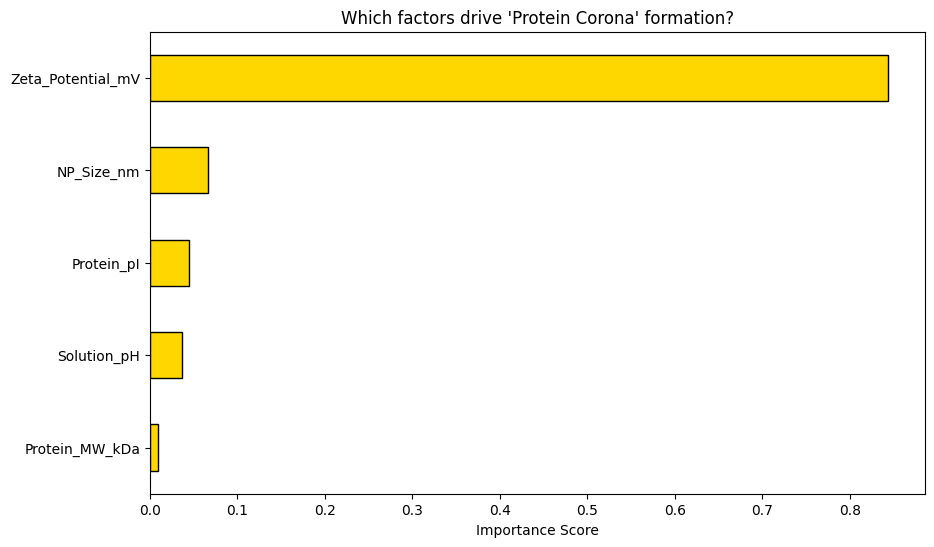


🎯 TEST PREDICTION (Gold Nanoparticle in Blood):
Result: 16.13 | Status: LOW (Stealth - Long Circulation)


In [ ]:
# NANO-PROTEIN CORONA PREDICTOR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("="*60)
print("🧬 NANOPARTICLE-PROTEIN CORONA PREDICTOR")
print("="*60)

# STEP 1: Generate Synthetic Biophysical Data
# We create 500 virtual experiments based on real Nano-Bio rules
np.random.seed(42)
n_samples = 500

data = {
    'NP_Size_nm': np.random.uniform(10, 200, n_samples),          # Diameter of Gold NP
    'Zeta_Potential_mV': np.random.uniform(-50, 50, n_samples),   # Surface Charge
    'Protein_MW_kDa': np.random.uniform(10, 150, n_samples),      # Protein Molecular Weight
    'Protein_pI': np.random.uniform(4, 10, n_samples),            # Isoelectric Point
    'Solution_pH': np.random.choice([5.5, 7.4, 8.0], n_samples)   # Blood pH vs Lysosome pH
}

df = pd.DataFrame(data)

# STEP 2: Create the "Target" (Binding Affinity) using a Bio-Formula
# Rule: Smaller, highly charged particles usually bind proteins more strongly
df['Binding_Affinity'] = (
    (1 / df['NP_Size_nm'] * 100) +
    (abs(df['Zeta_Potential_mV']) * 0.5) +
    (df['Protein_MW_kDa'] * 0.01) -
    (abs(df['Solution_pH'] - df['Protein_pI']) * 2)
)
# Add some "Lab Noise" to make it realistic
df['Binding_Affinity'] += np.random.normal(0, 2, n_samples)

print(f"✅ Dataset Created: {n_samples} Nanoparticle-Protein interactions simulated.")

# STEP 3: Train the AI (Gradient Boosting)
X = df.drop('Binding_Affinity', axis=1)
y = df['Binding_Affinity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
model.fit(X_train, y_train)

# STEP 4: Evaluate
y_pred = model.predict(X_test)
print(f"✅ Model R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"✅ Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

# STEP 5: Visualize Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='gold', edgecolor='black')
plt.title("Which factors drive 'Protein Corona' formation?")
plt.xlabel("Importance Score")
plt.show()

# STEP 6: Practical Prediction Function
def predict_corona_strength(size, charge, mw, pi, ph=7.4):
    input_data = pd.DataFrame([[size, charge, mw, pi, ph]], columns=X.columns)
    prediction = model.predict(input_data)[0]

    if prediction > 40:
        risk = "HIGH (Hard Corona - Rapid Clearance)"
    elif prediction > 20:
        risk = "MEDIUM (Soft Corona - Stable)"
    else:
        risk = "LOW (Stealth - Long Circulation)"

    return {"Affinity_Score": round(prediction, 2), "Biological_Identity": risk}

# Test Example
print("\n🎯 TEST PREDICTION (Gold Nanoparticle in Blood):")
test_res = predict_corona_strength(size=50, charge=-35, mw=66, pi=4.7)
print(f"Result: {test_res['Affinity_Score']} | Status: {test_res['Biological_Identity']}")